In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('OnlineRetail.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nNegative quantities (returns):", (df['Quantity'] < 0).sum())

Shape: (541909, 8)

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Negative quantities (returns): 10624


## Initial Inspection & Cleaning

Before building RFM features, we need to clean two known issues in this dataset: missing CustomerID (transactions without a customer can't be attributed to anyone for segmentation) and negative Quantity values (these represent returns/cancellations, not purchases).

In [3]:
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[df_clean['Quantity'] > 0]

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Rows before cleaning: 541909
Rows after cleaning: 397924
Rows removed: 143985


Rows missing CustomerID were dropped since they cannot be attributed to any customer for segmentation purposes. Rows with negative Quantity (returns/cancellations) were also removed, since RFM analysis should reflect actual purchasing behavior, not reversals. This leaves a clean transactional dataset ready for RFM feature engineering.

In [4]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Feature Engineering

Recency: days since each customer's last purchase (lower = more recently active)
Frequency: number of unique invoices per customer (higher = more frequent buyer)
Monetary: total amount spent per customer (higher = more valuable customer)

A snapshot date one day after the last transaction in the dataset is used as the reference point for calculating recency.

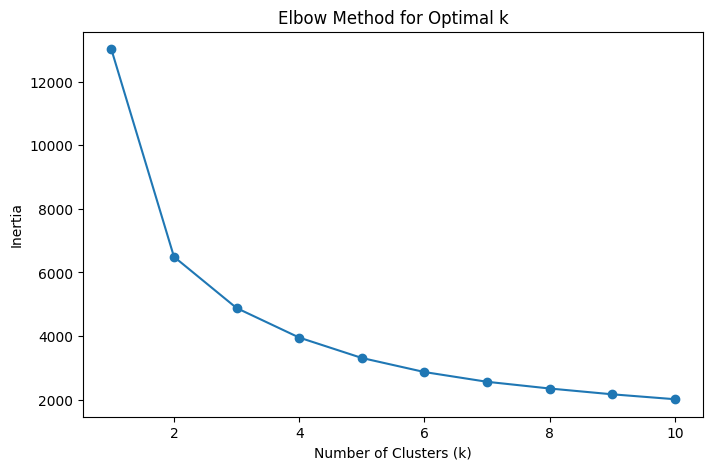

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Log-transform to reduce skewness (RFM is rarely normally distributed)
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Elbow method to find optimal k
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [6]:
# Fit KMeans with chosen k
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Profile clusters: mean R, F, M per cluster + count of customers
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'CustomerCount'}).round(1)

cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,18.7,2.1,538.2,839
1,12.1,13.6,8015.4,723
2,70.7,4.1,1791.1,1183
3,184.0,1.3,342.4,1594


Segment
Lost/Churned     1594
At Risk          1183
New/Potential     839
Champions         723
Name: count, dtype: int64


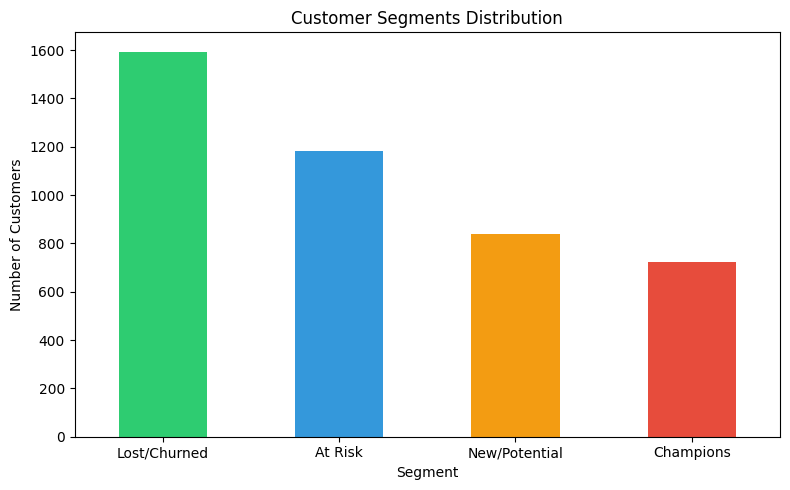

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,2,At Risk
12347.0,2,7,4310.00,1,Champions
12348.0,75,4,1797.24,2,At Risk
12349.0,19,1,1757.55,0,New/Potential
12350.0,310,1,334.40,3,Lost/Churned


In [7]:
# Map cluster numbers to business-friendly segment names
segment_map = {
    1: 'Champions',
    0: 'New/Potential',
    2: 'At Risk',
    3: 'Lost/Churned'
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Segment distribution
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar', color=['#2ecc71','#3498db','#f39c12','#e74c3c'])
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Save final segmented data
rfm.to_csv('customer_segments.csv')
rfm.head()

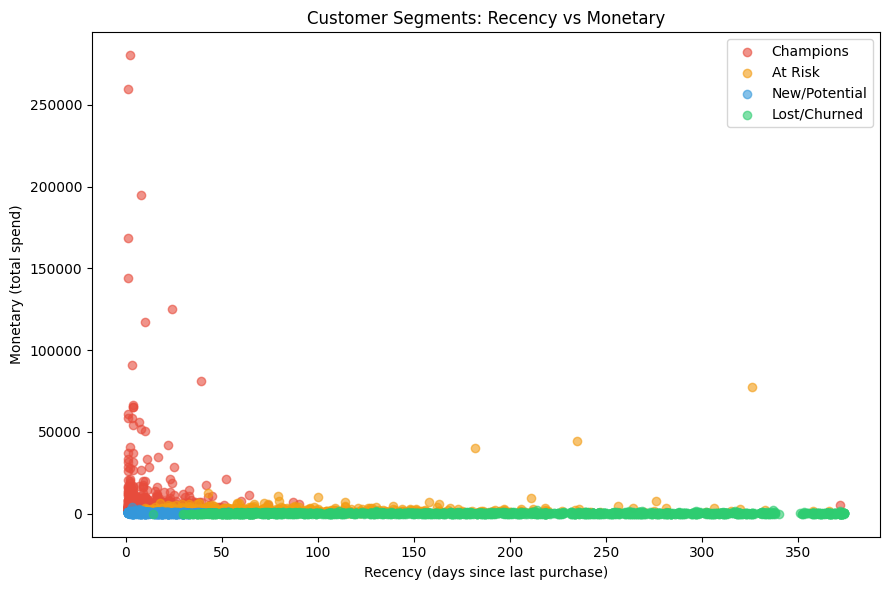

In [8]:
# Scatter plot: Recency vs Monetary, colored by segment
plt.figure(figsize=(9,6))
colors = {'Champions':'#e74c3c','At Risk':'#f39c12','New/Potential':'#3498db','Lost/Churned':'#2ecc71'}
for seg, color in colors.items():
    subset = rfm[rfm['Segment'] == seg]
    plt.scatter(subset['Recency'], subset['Monetary'], label=seg, alpha=0.6, color=color)

plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend)')
plt.title('Customer Segments: Recency vs Monetary')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusions

- Customers were segmented into 4 groups using K-Means clustering (k=4, chosen via the elbow method) on log-transformed, scaled RFM features.
- **Champions** (723 customers): recent, frequent, high spenders — the most valuable segment; prioritize retention and loyalty rewards.
- **New/Potential** (839 customers): recent but low frequency/spend — good targets for onboarding campaigns to build habit.
- **At Risk** (1,183 customers): moderate recency/frequency, declining engagement — target with re-engagement offers before they churn.
- **Lost/Churned** (1,594 customers): haven't purchased in ~6 months — largest group; may need win-back campaigns or can be deprioritized.
- Note: a few high one-time spenders (e.g., CustomerID 12346) are grouped by behavior pattern rather than total spend alone, since RFM clustering weighs recency and frequency as well as monetary value.